#### Import Libraries

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [24]:
# ==============================
# 2. Load Data
# ==============================
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [25]:
#trades.head()
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [26]:

trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [27]:
sentiment = sentiment[['date', 'classification', 'value']]
sentiment.head()

,date,classification,value
0,2018-02-01,Fear,30
1,2018-02-02,Extreme Fear,15
2,2018-02-03,Fear,40
3,2018-02-04,Extreme Fear,24
4,2018-02-05,Extreme Fear,11


#### Data Cleaning

In [28]:
valid_keywords = ['Long', 'Short', 'Buy', 'Sell']

trades = trades[trades['Direction'].astype(str).str.contains('|'.join(valid_keywords), na=False)]

def get_position_type(x):
    if 'Long' in str(x):
        return 'LONG'
    elif 'Short' in str(x):
        return 'SHORT'
    else:
        return 'UNKNOWN'

trades['position_type'] = trades['Direction'].apply(get_position_type)

def get_action(x):
    if 'Open' in str(x):
        return 'OPEN'
    elif 'Close' in str(x):
        return 'CLOSE'
    elif x in ['Buy', 'Sell']:
        return 'EXECUTION'
    else:
        return 'OTHER'

trades['action'] = trades['Direction'].apply(get_action)

trades = trades[trades['position_type'] != 'UNKNOWN']

In [29]:

trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

print(trades['Timestamp'].head())
print(trades['date'].nunique())

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
sentiment.rename(columns={'classification': 'Sentiment'}, inplace=True)



64   2024-10-27 03:33:20
65   2024-10-27 03:33:20
66   2024-10-27 03:33:20
67   2024-10-27 03:33:20
68   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]
7


#### Aggregate to Order Level

In [30]:

order_df = trades.groupby(['Account',"Coin", 'Order ID']).agg({
    'Execution Price': 'mean',
    'Size Tokens': 'sum',
    'Fee': 'sum',
    'Side': 'first',
    'Timestamp': 'first',
    'Closed PnL': 'sum'
}).reset_index()



print("\nOrders created:", len(order_df))


Orders created: 41502


#### Merge Sentiment

In [31]:


order_df = order_df.sort_values(['Account', 'Timestamp'])

order_df['date'] = order_df['Timestamp'].dt.date

df = order_df.merge(sentiment, on='date', how='left')

print("Missing sentiment rows:", df['Sentiment'].isna().sum())

df.head()

Missing sentiment rows: 3750


,Account,Coin,Order ID,Execution Price,Size Tokens,Fee,Side,Timestamp,Closed PnL,date,Sentiment,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,45991568323,3209.157143,135.0,121.032315,SELL,2024-10-27 03:33:20,0.0,2024-10-27,Greed,74.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,45993118565,3203.000000,146.0,46.763740,SELL,2024-10-27 03:33:20,0.0,2024-10-27,Greed,74.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,47935543269,3086.000000,100.0,30.859997,SELL,2024-10-27 03:33:20,0.0,2024-10-27,Greed,74.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,48323391431,3164.600000,300.0,94.937983,SELL,2024-10-27 03:33:20,0.0,2024-10-27,Greed,74.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,49214195955,3382.400000,100.0,33.823995,BUY,2024-10-27 03:33:20,-21227.0,2024-10-27,Greed,74.0


In [32]:
df.groupby('Sentiment').agg({
    'Closed PnL': ['mean', 'sum'],
    'Order ID': 'count'
})

Closed PnL               Order ID
                     mean           sum    count
Sentiment                                       
Extreme Greed  122.298197  1.769655e+05     1447
Fear           278.237209  6.478197e+06    23283
Greed           51.527157  5.276896e+05    10241
Neutral         35.797508  9.955287e+04     2781

#### Reconstruct Positions

In [33]:


df = df.sort_values(['Account', 'Coin', 'Timestamp'])

df['signed_size'] = np.where(df['Side'] == 'BUY',
                             df['Size Tokens'],
                             -df['Size Tokens'])

df['cum_position'] = df.groupby(['Account', 'Coin'])['signed_size'].cumsum()

df['position_closed'] = df['cum_position'] == 0

print("Closed positions count:", df['position_closed'].sum())



Closed positions count: 1975


#### Approximate Trade PnL

In [34]:

df['cash_flow'] = -df['signed_size'] * df['Execution Price']

trade_df = df.groupby([
    'Account',
    'Coin',
    df.groupby(['Account', 'Coin'])['position_closed'].cumsum()
]).agg({
    'cash_flow': 'sum',
    'Fee': 'sum',
    'Timestamp': ['min', 'max'],
    'Sentiment': 'first'
}) 

trade_df.columns = ['pnl', 'fee', 'entry_time', 'exit_time', 'sentiment']
trade_df = trade_df.reset_index()

trade_df['net_pnl'] = trade_df['pnl'] - trade_df['fee']
trade_df['duration'] = trade_df['exit_time'] - trade_df['entry_time']

trade_df['is_win'] = trade_df['net_pnl'] > 0

print("Total PnL:", trade_df['net_pnl'].sum())
print("\nTotal trades constructed:", len(trade_df))
print("Win rate:", trade_df['is_win'].mean())

Total PnL: 7264601.642524307

Total trades constructed: 2584
Win rate: 0.5472136222910217


#### Sharpe Ratio (Daily)

In [35]:

trade_df['date'] = trade_df['entry_time'].dt.date

daily_returns = trade_df.groupby('date')['net_pnl'].sum()

print("Days:", len(daily_returns))
print("Std:", daily_returns.std())

sharpe = daily_returns.mean() / daily_returns.std() if daily_returns.std() != 0 else 0
print("Sharpe:", sharpe)

# Annualized Sharpe
sharpe_annualized = sharpe * np.sqrt(252)
print("Annualized Sharpe:", sharpe_annualized)

Days: 7
Std: 2156566.043705503
Sharpe: 0.48122812546150323
Annualized Sharpe: 7.639259663165565


#### Sentiment Analysis

In [36]:

sentiment_perf = trade_df.groupby('sentiment').agg({
    'net_pnl': ['mean', 'sum'],
    'is_win': 'mean',
    'Account': 'count'
}).reset_index()
    
print(sentiment_perf)

       sentiment      net_pnl                  is_win Account
                         mean           sum      mean   count
0  Extreme Greed  2359.192135  9.035706e+05  0.509138     383
1           Fear    -3.072654 -4.009813e+03  0.566284    1305
2          Greed  9579.693733  5.594541e+06  0.539384     584
3        Neutral  2192.073297  3.463476e+05  0.601266     158


#### Strategy Insights

In [37]:


# Buy in Fear vs Buy in Greed
strategy = df.groupby(['Sentiment', 'Side'])['Closed PnL'].mean().reset_index()
print(strategy)

# Contrarian Strategy
contrarian = df[((df['Sentiment'].str.contains('Fear')) & (df['Side'] == 'BUY')) |
                 ((df['Sentiment'].str.contains('Greed')) & (df['Side'] == 'SELL'))]

print("Contrarian Avg PnL:", contrarian['Closed PnL'].mean())

       Sentiment  Side  Closed PnL
0  Extreme Greed   BUY  113.305308
1  Extreme Greed  SELL  132.274274
2           Fear   BUY  286.200229
3           Fear  SELL  267.423341
4          Greed   BUY   37.203143
5          Greed  SELL   66.170803
6        Neutral   BUY   44.332746
7        Neutral  SELL   28.959367
Contrarian Avg PnL: 222.53186292327365


#### Trader Clustering

In [38]:

trader_stats = trade_df.groupby('Account').agg({
    'net_pnl': ['sum', 'mean'],
    'is_win': 'mean',
    'duration': 'mean'
})

trader_stats.columns = ['total_pnl', 'avg_pnl', 'win_rate', 'avg_duration']
trader_stats = trader_stats.reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(trader_stats[['total_pnl', 'avg_pnl', 'win_rate']])

kmeans = KMeans(n_clusters=3, random_state=42)
trader_stats['cluster'] = kmeans.fit_predict(X)

cluster_summary = trader_stats.groupby('cluster')[[
    'total_pnl',
    'avg_pnl',
    'win_rate',
    'avg_duration'
]].mean()


def label_cluster(row):
    if row['total_pnl'] > 0 and row['win_rate'] > 0.5:
        return 'Profitable Traders'
    elif row['total_pnl'] < 0:
        return 'Losing Traders'
    else:
        return 'Neutral Traders'

cluster_summary['type'] = cluster_summary.apply(label_cluster, axis=1)

print(cluster_summary)


            total_pnl        avg_pnl  win_rate               avg_duration  \
cluster                                                                     
0        1.018023e+06  138112.138136  0.468953 34 days 04:08:18.017446471   
1        2.238849e+04   -6934.668295  0.545869 13 days 10:34:17.355896309   
2        1.592385e+06  144762.288634  0.818182 10 days 12:31:30.909090909   

                       type  
cluster                      
0           Neutral Traders  
1        Profitable Traders  
2        Profitable Traders  


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


####  Risk Analysis (Drawdown)

In [39]:

equity_curve = daily_returns.cumsum()
rolling_max = equity_curve.cummax()
drawdown = equity_curve - rolling_max

print("Max Drawdown:", drawdown.min())

Max Drawdown: -258862.05243963705


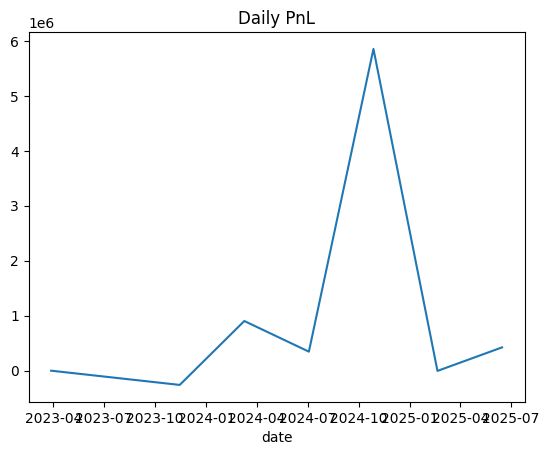

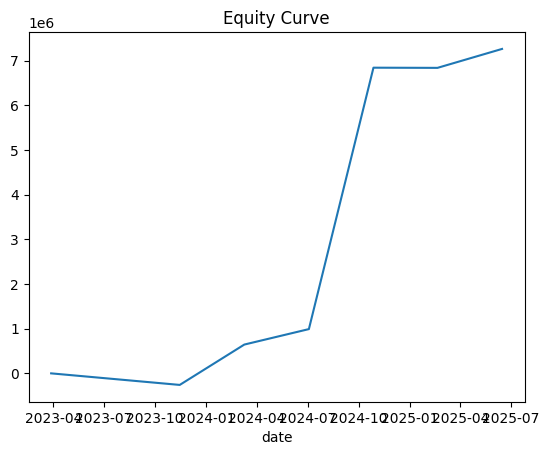

In [40]:
# ==============================
# 13. Visualizations
# ==============================
plt.figure()
daily_returns.plot(title='Daily PnL')
plt.show()

plt.figure()
equity_curve.plot(title='Equity Curve')
plt.show()

#### Visualizations

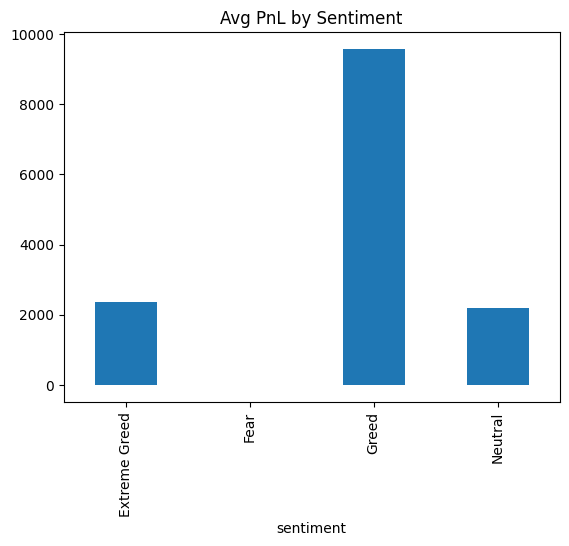

In [41]:


plt.figure()
sentiment_perf.set_index('sentiment')['net_pnl']['mean'].plot(kind='bar')
plt.title('Avg PnL by Sentiment')
plt.show()



#### Save Outputs

In [43]:

trade_df.to_csv('final_trade.csv', index=False)
trader_stats.to_csv('final_trader_cluster.csv', index=False)

print("\nFINAL ANALYSIS COMPLETE")


FINAL ANALYSIS COMPLETE


#### Additional Insights

In [44]:


unique_values = trades['Direction'].unique()
print(unique_values)
keep_actions = ['Open Long', 'Close Long', 'Open Short', 'Close Short']

trades = trades[trades['Direction'].isin(keep_actions)]
print(trades['Direction'].value_counts())

trades['Action'] = trades['Direction'].str.split().str[0]  # Gets 'Open' or 'Close'
trades['Position_Side'] = trades['Direction'].str.split().str[1]  # Gets 'Long' or 'Short'

# Verify
print(trades[['Direction', 'Action', 'Position_Side']].head(10))
print("\nUnique Actions:", trades['Action'].unique())
print("Unique Position Sides:", trades['Position_Side'].unique())

['Open Long' 'Close Long' 'Open Short' 'Close Short' 'Long > Short'
 'Short > Long' 'Liquidated Isolated Short']
Direction
Open Long      49895
Close Long     48678
Open Short     39741
Close Short    36013
Name: count, dtype: int64
    Direction Action Position_Side
64  Open Long   Open          Long
65  Open Long   Open          Long
66  Open Long   Open          Long
67  Open Long   Open          Long
68  Open Long   Open          Long
69  Open Long   Open          Long
70  Open Long   Open          Long
71  Open Long   Open          Long
72  Open Long   Open          Long
73  Open Long   Open          Long

Unique Actions: ['Open' 'Close']
Unique Position Sides: ['Long' 'Short']


## Key Alpha Discovery


Contrary to common market intuition, the highest average profitability in this dataset occurs during Greed phases rather than Fear.

This suggests that traders are more successful when following momentum rather than adopting purely contrarian strategies.

Additionally, while win rates are relatively stable across sentiment regimes, profitability varies significantly, reinforcing that trade quality and magnitude not just accuracy drive returns.

This indicates that market conditions during Greed phases may offer more sustained trends, enabling traders to capture larger directional moves.

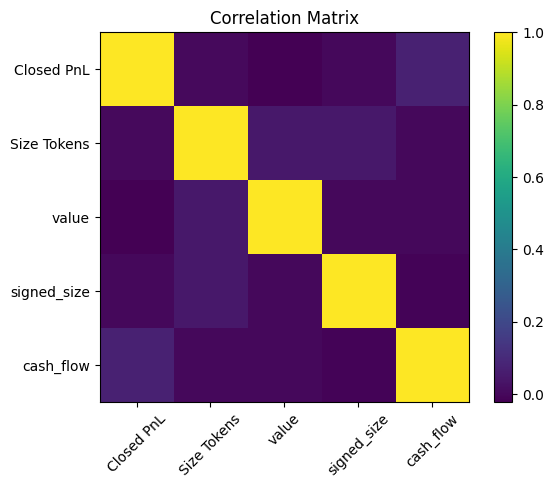

In [45]:
cols = ['Closed PnL', 'Size Tokens', 'value', 'signed_size', 'cash_flow']

corr = df[cols].corr()

import matplotlib.pyplot as plt

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title("Correlation Matrix")
plt.show()


The correlation matrix reveals that Closed PnL has near-zero correlation with key trading variables such as trade size, value, and cash flow.

This indicates that profitability is not driven by any single linear factor, but rather by a combination of timing, market conditions, and trader behavior.

Notably, this reinforces the importance of sentiment-based and volatility-driven strategies, as simple metrics like trade size or capital deployed do not explain performance outcomes.

This insight highlights the complexity of trading systems and suggests that successful strategies must account for multi-dimensional and non-linear relationships.

This motivates further analysis into sentiment-driven performance, where we observe significantly stronger patterns in trader profitability.

This analysis highlights that trading edge lies not in trade size or frequency, but in identifying favorable market regimes driven by sentiment and volatility.